#**Linear Classifier from Scratch in Tensorflow**

We are now going to go through the book's example of implementing a linear classifier from scratch using Tensorflow. We already demonstrated our procedure using Keras + Tensorflow, so this is just another example to reinforce understanding.

#*Simulate Data*

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # for cross tabulation to make confusion matrix.

# We will ultimately have 2000 observations, 1000 1's and 1000 0's.
# We are drawing a two inputs (x's) which are jointly normal, taking on average values of 0 and 3 when the outcome is 0, and values of 3 and 0 when the outcome is 1.
# The cov are covariance matrices, defining how the two x's associate with one another.
num_samples_per_class = 1000

negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

# Now we stack the two vector pairs together into a single dataset.
samples = np.vstack((negative_samples,positive_samples))

labels = np.hstack((np.zeros((1000)),__fill__))

Plotting the resultant data...

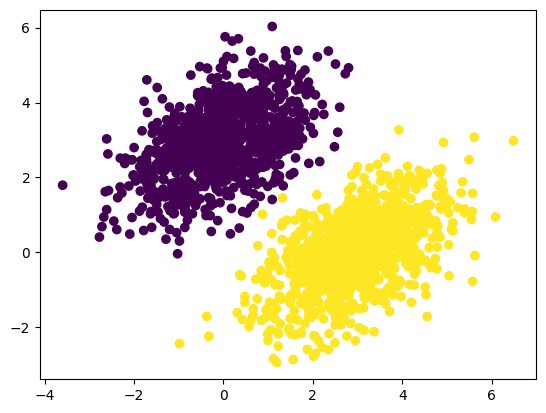

In [19]:
# We make a scatter plot of the first and second columns of the samples matrix (x1 and x2)
# The colors are assigned based on the target label for each observation.
plt.scatter(samples[:,0],samples[:,1],c=labels)
plt.show()

#*Fit a Keras Model*

We are going to train a classifier with the Keras Sequential API to simplify things, and we will incorporate a holdout dataset for model evaluation.

In [23]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(1, activation="linear")
])

# Here we use mse as our loss to train the model
model.compile(optimizer="rmsprop",
              loss="__fill__",
              metrics=["mae","accuracy"])

# Finally, when we call the fit function, we separately specify training data and a validation split.
# We indicate the latter using the validation_split argument.
# We take the constructed inputs and labels (training set) as the first two parameters to call the model fit function.
history = model.fit(
    __fill__,
    __fill__,
    epochs=10,
    batch_size=10,
    validation_split=__fill__,
    shuffle=True # this is set True by default in any case!
)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9625 - loss: 0.2989 - mae: 2.9298 - val_accuracy: 0.9100 - val_loss: 0.5590 - val_mae: 1.2140
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.1397 - mae: 2.8433 - val_accuracy: 0.9575 - val_loss: 0.2727 - val_mae: 1.3291
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9869 - loss: 0.0775 - mae: 2.7890 - val_accuracy: 0.9775 - val_loss: 0.1944 - val_mae: 1.4591
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9931 - loss: 0.0600 - mae: 2.7394 - val_accuracy: 0.9800 - val_loss: 0.1064 - val_mae: 1.5900
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9944 - loss: 0.0191 - mae: 2.7046 - val_accuracy: 0.9875 - val_loss: 0.0933 - val_mae: 1.7328
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0146 - mae: 2.6681 - val_accuracy: 0.9925 - val_loss: 0.0556 - val_mae: 1.8403
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 

After the model fitting is complete, we call the evaluate function, and pass it the validation data (or, typically, some test / holdout data). Here we are cheating and just passing training data again! Note that batch size here is not the same batch size in the fit() call. Batch size here refers to batches of observations in validation data to run through (predictions and loss calculations)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9990 - loss: 0.0032 - mae: 2.4925      


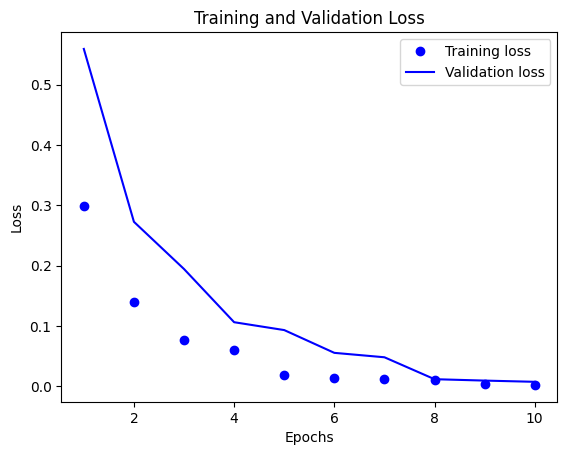

In [26]:
# We take the inputs and targets as the first two parameters to call the model evaluation function.
loss_and_metrics = model.evaluate(__fill__, __fill__, batch_size=128)

history_dict = history.history
history_dict.keys()

# Notice that there's basically no overfitting going on.
# Because there's no noise in the data for the network to fit to!
trn_loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(trn_loss_values) + 1)
plt.plot(epochs, trn_loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()